<a href="https://colab.research.google.com/github/VSKoffl/My-first-python-ml-work/blob/main/Next_Word_Prediction_using_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
faqs = """About the Program
What is the course fee for  Data Science Mentorship Program (DSMP 2023)
The course follows a monthly subscription model where you have to make monthly payments of Rs 799/month.
What is the total duration of the course?
The total duration of the course is 7 months. So the total course fee becomes 799*7 = Rs 5600(approx.)
What is the syllabus of the mentorship program?
We will be covering the following modules:
Python Fundamentals
Python libraries for Data Science
Data Analysis
SQL for Data Science
Maths for Machine Learning
ML Algorithms
Practical ML
MLOPs
Case studies
You can check the detailed syllabus here - https://learnwith.campusx.in/courses/CampusX-Data-Science-Mentorship-Program-637339afe4b0615a1bbed390
Will Deep Learning and NLP be a part of this program?
No, NLP and Deep Learning both are not a part of this program’s curriculum.
What if I miss a live session? Will I get a recording of the session?
Yes all our sessions are recorded, so even if you miss a session you can go back and watch the recording.
Where can I find the class schedule?
Checkout this google sheet to see month by month time table of the course - https://docs.google.com/spreadsheets/d/16OoTax_A6ORAeCg4emgexhqqPv3noQPYKU7RJ6ArOzk/edit?usp=sharing.
What is the time duration of all the live sessions?
Roughly, all the sessions last 2 hours.
What is the language spoken by the instructor during the sessions?
Hinglish
How will I be informed about the upcoming class?
You will get a mail from our side before every paid session once you become a paid user.
Can I do this course if I am from a non-tech background?
Yes, absolutely.
I am late, can I join the program in the middle?
Absolutely, you can join the program anytime.
If I join/pay in the middle, will I be able to see all the past lectures?
Yes, once you make the payment you will be able to see all the past content in your dashboard.
Where do I have to submit the task?
You don’t have to submit the task. We will provide you with the solutions, you have to self evaluate the task yourself.
Will we do case studies in the program?
Yes.
Where can we contact you?
You can mail us at nitish.campusx@gmail.com
Payment/Registration related questions
Where do we have to make our payments? Your YouTube channel or website?
You have to make all your monthly payments on our website. Here is the link for our website - https://learnwith.campusx.in/
Can we pay the entire amount of Rs 5600 all at once?
Unfortunately no, the program follows a monthly subscription model.
What is the validity of monthly subscription? Suppose if I pay on 15th Jan, then do I have to pay again on 1st Feb or 15th Feb
15th Feb. The validity period is 30 days from the day you make the payment. So essentially you can join anytime you don’t have to wait for a month to end.
What if I don’t like the course after making the payment. What is the refund policy?
You get a 7 days refund period from the day you have made the payment.
I am living outside India and I am not able to make the payment on the website, what should I do?
You have to contact us by sending a mail at nitish.campusx@gmail.com
Post registration queries
Till when can I view the paid videos on the website?
This one is tricky, so read carefully. You can watch the videos till your subscription is valid. Suppose you have purchased subscription on 21st Jan, you will be able to watch all the past paid sessions in the period of 21st Jan to 20th Feb. But after 21st Feb you will have to purchase the subscription again.
But once the course is over and you have paid us Rs 5600(or 7 installments of Rs 799) you will be able to watch the paid sessions till Aug 2024.
Why lifetime validity is not provided?
Because of the low course fee.
Where can I reach out in case of a doubt after the session?
You will have to fill a google form provided in your dashboard and our team will contact you for a 1 on 1 doubt clearance session
If I join the program late, can I still ask past week doubts?
Yes, just select past week doubt in the doubt clearance google form.
I am living outside India and I am not able to make the payment on the website, what should I do?
You have to contact us by sending a mail at nitish.campusx@gmai.com
Certificate and Placement Assistance related queries
What is the criteria to get the certificate?
There are 2 criterias:
You have to pay the entire fee of Rs 5600
You have to attempt all the course assessments.
I am joining late. How can I pay payment of the earlier months?
You will get a link to pay fee of earlier months in your dashboard once you pay for the current month.
I have read that Placement assistance is a part of this program. What comes under Placement assistance?
This is to clarify that Placement assistance does not mean Placement guarantee. So we dont guarantee you any jobs or for that matter even interview calls. So if you are planning to join this course just for placements, I am afraid you will be disappointed. Here is what comes under placement assistance
Portfolio Building sessions
Soft skill sessions
Sessions with industry mentors
Discussion on Job hunting strategies
"""

This project is about next word generation. We are going to approach this as a task to build a text generator. The learning will be sort of a supervised learning.

To create the dataset, we first pick a sentence and go word-by-word and create a dataset where if the first word or first few words of the sentence are input, then output is the immediate next word.

For instance,
Let the sentence be "I am VSK", so for input "I" output would be "am", for input "I am" output would be "VSK". We will take every sentence in the text and do replicate this process. One sentence above became 2 data points. Hence, we can expect a fairly big data set.

But the task also involves enumeration of these values.

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([faqs])

A look on tokenizer

| Function/Attribute   | Description                                                                                                                              | Example                                | Result                                             |
|----------------------|------------------------------------------------------------------------------------------------------------------------------------------|----------------------------------------|----------------------------------------------------|
| `char_level`         | Boolean, indicates if tokenization was done at character level (True) or word level (False).                                             | `tokenizer.char_level`                 | `False` (for current tokenizer)                    |
| `document_count`     | Integer, total number of documents (texts) used to fit the `Tokenizer`.                                                                  | `tokenizer.document_count`             | `1`                                                |
| `filters`            | String, characters to filter out from text (e.g., punctuation).                                                                          | `tokenizer.filters`                    | `!"#$%&()*+,-./:;<=>?@[\]^_`{|}~\t\n`           |
| `fit_on_texts(texts)`| Updates internal vocabulary based on a list of texts. Creates the `word_index` and `word_counts`.                                          | `tokenizer.fit_on_texts(['new text'])` | (Internal state of tokenizer changes)              |
| `get_config()`       | Returns the `Tokenizer` configuration as a Python dictionary.                                                                            | `tokenizer.get_config()`               | `{'num_words': None, 'filters': '...', ...}`       |
| `index_docs`         | Dictionary, mapping words to the number of documents they appeared in.                                                                   | `tokenizer.index_docs['program']`      | `3`                                                |
| `index_word`         | Dictionary, mapping word indices back to words.                                                                                          | `tokenizer.index_word[1]`              | `'the'`                                            |
| `lower`              | Boolean, indicates if text was converted to lowercase before tokenization.                                                               | `tokenizer.lower`                      | `True` (default behavior)                          |
| `num_words`          | Integer, the maximum number of words to keep, based on word frequency. Only the most common `num_words` words will be kept.             | `tokenizer.num_words`                  | `None` (if not specified during init)              |
| `oov_token`          | String, token to replace out-of-vocabulary words during `texts_to_sequences` or `texts_to_matrix`.                                       | `tokenizer.oov_token`                  | `None` (if not specified during init)              |
| `sequences_to_texts` | Transforms a list of sequence of indices (integers) back into a list of texts (strings).                                                 | `tokenizer.sequences_to_texts([[1,2]])`| `['the course']` (example)                         |
| `sequences_to_matrix`| Converts a list of sequences into a matrix (e.g., 'binary', 'count', 'tfidf', 'freq').                                                   | `tokenizer.sequences_to_matrix([[1]])` | `array([[0., 1., 0., ...]])`                       |
| `split`              | String, character or regex used to split texts into words.                                                                               | `tokenizer.split`                      | `' '`                                              |
| `texts_to_sequences` | Transforms each text in a list of texts to a sequence of integers (word indices).                                                        | `tokenizer.texts_to_sequences(['the course'])` | `[[1, 2]]` (example)                               |
| `texts_to_matrix`    | Converts a list of texts to a matrix (e.g., 'binary', 'count', 'tfidf', 'freq').                                                         | `tokenizer.texts_to_matrix(['the course'])` | `array([[0., 1., 1., ...]])`                       |
| `to_json()`          | Returns a JSON string containing the `Tokenizer` configuration.                                                                          | `tokenizer.to_json()`                  | `'{ "class_name": "Tokenizer", ... }'`         |
| `word_counts`        | Dictionary, mapping words to their absolute frequency (number of times they appeared).                                                   | `tokenizer.word_counts['the']`         | `13` (example)                                     |
| `word_docs`          | Dictionary, mapping words to the number of documents they appeared in (same as `index_docs` typically).                                  | `tokenizer.word_docs['the']`           | `1`                                                |
| `word_index`         | Dictionary, mapping words to their unique integer index. The indices are 1-based.                                                        | `tokenizer.word_index['the']`          | `1`                                                |

In [14]:
print(tokenizer.word_index)

{'the': 1, 'you': 2, 'i': 3, 'to': 4, 'a': 5, 'of': 6, 'is': 7, 'have': 8, 'will': 9, 'can': 10, 'what': 11, 'course': 12, 'program': 13, 'in': 14, 'for': 15, 'all': 16, 'sessions': 17, 'on': 18, 'be': 19, 'and': 20, 'this': 21, 'if': 22, 'am': 23, 'pay': 24, 'payment': 25, 'make': 26, 'we': 27, 'do': 28, 'subscription': 29, 'where': 30, 'rs': 31, 'so': 32, 'campusx': 33, 'session': 34, 'our': 35, 'paid': 36, 'join': 37, 'able': 38, 'your': 39, 'website': 40, 'placement': 41, 'fee': 42, 'data': 43, 'monthly': 44, 'month': 45, 'not': 46, 'get': 47, 'yes': 48, 'once': 49, 'past': 50, 'feb': 51, 'assistance': 52, 'science': 53, '7': 54, '5600': 55, 'are': 56, 'watch': 57, 'google': 58, 'by': 59, 'com': 60, 'mail': 61, 'from': 62, 'contact': 63, 'us': 64, 'at': 65, 'or': 66, 'doubt': 67, 'mentorship': 68, 'payments': 69, '799': 70, 'total': 71, 'duration': 72, 'months': 73, 'learning': 74, 'case': 75, 'here': 76, 'https': 77, 'part': 78, 'see': 79, 'late': 80, 'dashboard': 81, 'task': 82, 

We now try to create the dataset

In [16]:
print(faqs.split('\n')[:5])

['About the Program', 'What is the course fee for  Data Science Mentorship Program (DSMP 2023)', 'The course follows a monthly subscription model where you have to make monthly payments of Rs 799/month.', 'What is the total duration of the course?', 'The total duration of the course is 7 months. So the total course fee becomes 799*7 = Rs 5600(approx.)']


In [20]:
print(tokenizer.texts_to_sequences(["Hi, My Name is Nitish"]))

[[7, 84]]


In [24]:
input_sequences = []
for sentence in faqs.split("\n"):
  tokenized_sentence = tokenizer.texts_to_sequences([sentence])[0]
  for i in range(1,len(tokenized_sentence)):
    input_sequences.append(tokenized_sentence[:i+1])

In [25]:
input_sequences[:5]

[[93, 1], [93, 1, 13], [11, 7], [11, 7, 1], [11, 7, 1, 12]]

For padding, we need to know the max number of words in a sentence. Padding, btw, is being done to take care of the varying length of all the sentences in the input_sequences list

In [27]:
max_len = max([len(x) for x in input_sequences])

In [28]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [30]:
padded_input_sequences = pad_sequences(input_sequences,maxlen = max_len,padding = 'pre')

In [127]:
padded_input_sequences

array([[  0,   0,   0, ...,   0,  93,   1],
       [  0,   0,   0, ...,  93,   1,  13],
       [  0,   0,   0, ...,   0,  11,   7],
       ...,
       [  0,   0,   0, ..., 279,  18, 280],
       [  0,   0,   0, ...,  18, 280, 281],
       [  0,   0,   0, ..., 280, 281, 282]], dtype=int32)

In [31]:
x = padded_input_sequences[:,:-1]
y = padded_input_sequences[:,-1]

In [34]:
from tensorflow.keras.utils import to_categorical

In [35]:
y_new = to_categorical(y,num_classes=len(tokenizer.word_index)+1)
# +1 is because tokenizer starts indexing with number 1 and one hot encoder
# starts from 0, hence to make sure all the words are used, +1 is used

In [36]:
y_new

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

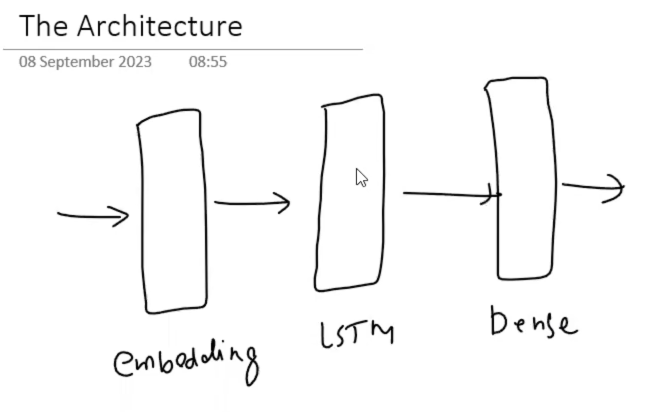

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [106]:
model = Sequential()
model.add(Embedding(input_dim = len(tokenizer.word_index)+1, output_dim = 100))
model.add(LSTM(150))
model.add(Dense(len(tokenizer.word_index)+1,activation="softmax"))

In [107]:
model.compile(loss = "categorical_crossentropy",optimizer = "adam", metrics = ['accuracy'])

In [113]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 56, 100)        │        28,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 150)            │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 283)            │        42,733 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 664,901 (2.54 MB)

 Trainable params: 221,633 (865.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 443,268 (1.69 MB)

In [111]:
model.fit(x,y_new,epochs = 100)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.9386 - loss: 0.3484
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.9432 - loss: 0.3331
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.9455 - loss: 0.3214
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.9467 - loss: 0.3069
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.9432 - loss: 0.2956
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.9421 - loss: 0.2871
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.9455 - loss: 0.2763
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.9502 - loss: 0.2664
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.9467 - loss: 0.2584
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.9421 - loss: 0.2509
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.9467 - loss: 0.2448
Epoch 12/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/s

In [137]:
text = "monthly payments"
import time
import numpy as np
tk_text = tokenizer.texts_to_sequences([text])
padded_tk_text = pad_sequences(tk_text,maxlen=max_len,padding='pre')
pos = np.argmax(model.predict([padded_tk_text]))
for word,index in tokenizer.word_index.items():
  if index == pos:
    text = text + " " + word
    print(text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
monthly payments on


In [144]:
text2 = input()
for i in range(5):
  # Must pass text inside list
  tk_text = tokenizer.texts_to_sequences([text2])
  # Pass the text to sequence out put in raw form
  padded_tk_text = pad_sequences(tk_text,maxlen= max_len,padding='pre')
  # Must pass list of lists
  pos2 = np.argmax(model.predict([padded_tk_text]))
  for word, index in tokenizer.word_index.items():
    if index == pos2:
      text2 = text2 + " " + word
      print(text2)

'You will have to fill a google form provided'